# 2D Grating Coupler

This notebook demonstrates **2D FDTD in the XZ cross-section plane** using `gsim.meep`. Unlike the top-down XY effective-index sim, this one models the vertical stack (substrate / BOX / core / cladding) and a Gaussian-beam fiber source above the chip — the standard grating-coupler workflow.


**Requirements:** GDSFactory+ account for cloud simulation.

### Load a grating coupler + feed straight

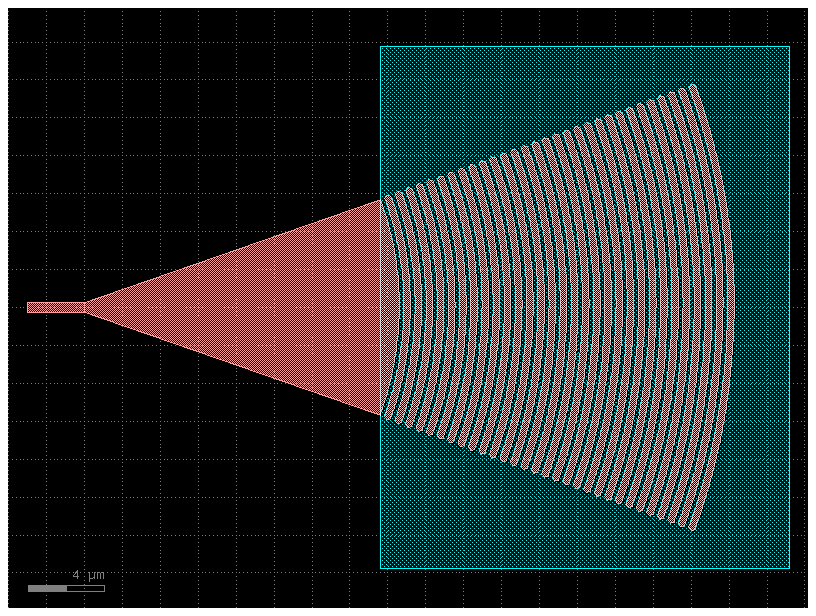

In [1]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.Component()
gc = gf.components.grating_coupler_elliptical(fiber_angle=0.0)

gc_r = c.add_ref(gc)
s_r = c.add_ref(gf.components.straight(length=3))
s_r.connect("o1", gc_r.ports["o1"])
c.add_port("o2", port=s_r.ports["o2"])
c

### Configure the XZ 2D simulation

Key differences from the XY notebook:
- `sim.solver(plane="xz", is_3d=False)` picks the vertical cross-section sim.
- `sim.source_fiber(...)` replaces the port-based mode source.
- `sim.monitors = ["o2"]` monitors the waveguide end (feed straight).

In [2]:
from gsim import meep

sim = meep.Simulation()

sim.geometry(component=c)
sim.materials = {"si": 3.47, "SiO2": 1.44}

sim.solver(resolution=25, is_3d=False, plane="xz", save_animation=True)
sim.solver.stop_when_energy_decayed()

sim.source_fiber(
    x=25.0,
    z=2,
    angle_deg=-6.0,
    waist=5.2,
    wavelength=1.55,
    wavelength_span=0.06,
    polarization="TE",
)

sim.monitors = ["o2"]
sim.domain(pml=1.0, margin=0.5)
sim.num_freqs = 21

print(sim.validate_config())

Stack validation: PASSED
Warnings:
  - No stack configured. Will use active PDK with defaults.
  - Stopping: energy_decay (dt=20.0, decay_by=0.01, cap=2000.0)


### Preview the XZ cross-section

simulation.py:713: UserWarning: Material 'Aluminum' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('Aluminum', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:713: UserWarning: Material 'TiN' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('TiN', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:713: UserWarning: Material 'ge' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('ge', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:713: UserWarning: Material 'passive' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('passive', refractive_index=...) to include it.
  material_data = resolve_materials(


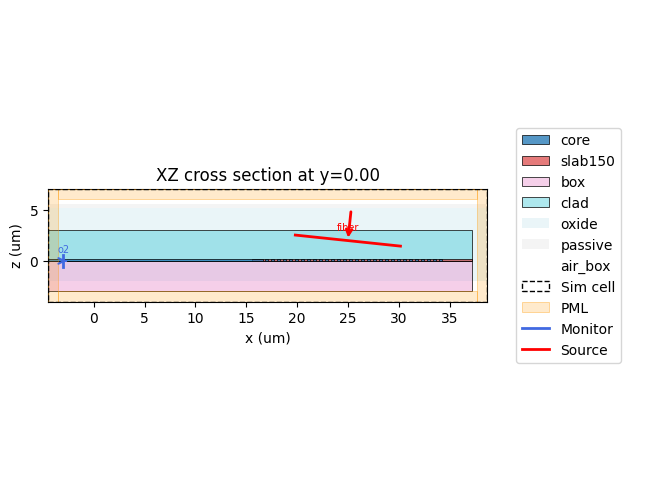

In [3]:
sim.plot_2d(slices="y")

### Run the simulation

In [4]:
result = sim.run()

  meep-d6ec4c4b  completed  2m 06s


Extracting results.tar.gz...
Downloaded 325 files to sim-data-meep-d6ec4c4b


In [5]:
result.plot_interactive()

In [6]:
result.show_animation()